## 2. Training CNN with the CIFAR10 dataset
Here I will show my optimized script to train my CNN model based on my hardware capabities.


In [29]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #run_epoch, train_simple_network_EZA

print(" dl_utils loaded")

 dl_utils loaded


In [27]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

### Hardware optimization
- Force GPU usage with `torch.backends.cudnn.benchmark`
- Enable Automatic Mixed Precision (AMP): Allows my RTX 2080 Ti to do FP16 math.

In [3]:
# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = True  # Speeds up CNN training with fixed input sizes

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')


Device available: cuda


### Data Loading and exploration
Load the CIFAR10 dataset from `torchvision` to build the CNN.

In [4]:
import matplotlib.pyplot as plt
from collections import Counter

In [19]:
# Load raw data (no transforms) for exploration
train_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

In [6]:
# Size and shape
print(f'Train size : {len(train_raw)}')
print(f'Test size : {len(test_raw)}')
print(f'Image array shape: {train_raw.data.shape}')
print(f'Classess: {train_raw.classes}')
print(f'Number of classes: {len(train_raw.classes)}')

Train size : 50000
Test size : 10000
Image array shape: (50000, 32, 32, 3)
Classess: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10


In [7]:
# Class distribution
label_counts = Counter([label for _, label in train_raw])
for cls, count in sorted(label_counts.items()):
    print(f' Class {train_raw.classes[cls]}: {count} samples')

 Class airplane: 5000 samples
 Class automobile: 5000 samples
 Class bird: 5000 samples
 Class cat: 5000 samples
 Class deer: 5000 samples
 Class dog: 5000 samples
 Class frog: 5000 samples
 Class horse: 5000 samples
 Class ship: 5000 samples
 Class truck: 5000 samples


In [15]:
# Pixel statistics: Inform normalization
data = train_raw.data / 255.0       # Normalize to [0,1] first
print(f'\nPer-channel mean: {data.mean(axis=(0,1,2))}')
print(f'Per-channel std: {data.std(axis=(0,1,2))}')


Per-channel mean: [0.49139968 0.48215841 0.44653091]
Per-channel std: [0.24703223 0.24348513 0.26158784]


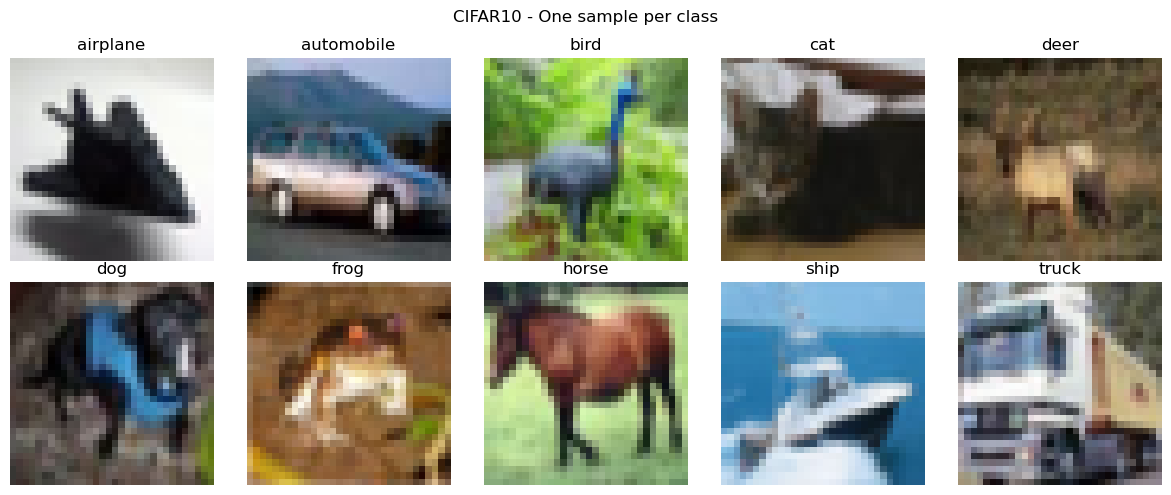

In [25]:
# Visualize samples per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR10 - One sample per class')
seen = {}
for img, label in train_raw:
    if label not in seen:
        seen[label] = img
    if len(seen) == 10:
        break

for ax, (label, img) in zip(axes.flat, sorted(seen.items())):
    ax.imshow(img)
    ax.set_title(train_raw.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.savefig('./data/others/cifar10_exploration.png', dpi=150)

In [ ]:
# Download the CIFAR10 data set

cifar10_data_train = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=transforms.ToTensor())
cifar10_data_test = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=transforms.ToTensor())

In [ ]:
# Create the train DataLoaders
batch_s = 128 #Batch size
cifar10_train_loader = DataLoader(
    cifar10_data_train,
    batch_size=batch_s, 
    shuffle=True,
    num_workers=4,
    pin_memory=True,  # Locks memory for faster CPU-->GPU transfer
    persistent_workers=True  # Keeps workers alive between epochs (faster)
)

cidar10_test_loader = DataLoader(cifar10_data_test, batch_size=B)

SyntaxError: '(' was never closed (4146544560.py, line 3)